# Sentinel-1 Interferogram with openEO

## ESA ClouDInSAR

**Authors:**  
_Mattia Callegari, Eurac Research_  
_Michele Claus, Eurac Research_  
_Emile Sonneveld, VITO_

**Release Date:**  
April 14, 2026

This notebook shows how to generate a time series of Sentinel-1 interferometric coherence, wrapped interferograms, and unwrapped interferograms for user‑defined interferometric pairs, geocoded in WGS84/EPSG:4326.  

The area of interest is defined at burst level, using the Sentinel‑1 burst_id and sub_swath, ensuring precise spatial targeting and consistent geometry across acquisitions.  

The interferometric pairs to be processed are explicitly provided by the user through the InSAR_pair list, allowing full control over temporal baselines.

The workflow is implemented using ESA SNAP operators and is defined as a Common Workflow Language (CWL) pipeline [sar_interferogram.cwl](https://github.com/cloudinsar/s1-workflows/blob/main/cwl/sar_interferogram.cwl).  

The generated interferograms are fully suitable for multi‑temporal interferometric analysis. In particular, the outputs can be directly used as input to multi‑temporal InSAR toolkits such as MintPy, enabling time‑series deformation analysis using methods like SBAS or Persistent Scatterer approaches.

In [2]:
import openeo
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

/home/mclaus/envs/cloudinsar/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()
stac_resource = connection.datacube_from_process(
"sentinel1_sar_interferogram",
namespace="https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/refs/heads/main/algorithm_catalog/eurac/sentinel1_sar_interferogram/openeo_udp/sentinel1_sar_interferogram.json",
**{
    "InSAR_pairs": [
        [
            "2018-01-28",
            "2018-02-03"
        ]
    ],
    "burst_id": 329488,
    "coherence_window_az": 2,
    "coherence_window_rg": 10,
    "n_az_looks": 1,
    "n_rg_looks": 4,
    "polarization": "VH",
    "sub_swath": "IW2"
}
)

job = stac_resource.create_job(title="sentinel1_sar_interferogram test")
job.start_and_wait()
job.get_results().download_files()

Authenticated using refresh token.
0:00:00 Job 'j-26041414085248c8a2f3a1c37ae5d0d9': send 'start'
0:00:24 Job 'j-26041414085248c8a2f3a1c37ae5d0d9': created (progress 0%)
0:00:29 Job 'j-26041414085248c8a2f3a1c37ae5d0d9': created (progress 0%)
0:00:36 Job 'j-26041414085248c8a2f3a1c37ae5d0d9': created (progress 0%)
0:00:44 Job 'j-26041414085248c8a2f3a1c37ae5d0d9': created (progress 0%)
0:00:54 Job 'j-26041414085248c8a2f3a1c37ae5d0d9': created (progress 0%)
0:01:07 Job 'j-26041414085248c8a2f3a1c37ae5d0d9': created (progress 0%)
0:01:22 Job 'j-26041414085248c8a2f3a1c37ae5d0d9': created (progress 0%)
0:01:42 Job 'j-26041414085248c8a2f3a1c37ae5d0d9': running (progress N/A)
0:02:06 Job 'j-26041414085248c8a2f3a1c37ae5d0d9': running (progress N/A)
0:02:36 Job 'j-26041414085248c8a2f3a1c37ae5d0d9': running (progress N/A)
0:03:14 Job 'j-26041414085248c8a2f3a1c37ae5d0d9': running (progress N/A)
0:04:01 Job 'j-26041414085248c8a2f3a1c37ae5d0d9': running (progress N/A)
0:04:59 Job 'j-26041414085248c8a2

[PosixPath('/home/mclaus/cloudinsar/s1-workflows/examples/phase_coh_20180128T062713_20180203T062631.tif'),
 PosixPath('/home/mclaus/cloudinsar/s1-workflows/examples/job-results.json')]

# Visualization of the results

Visualize the band names

In [6]:
with rasterio.open('phase_coh_20180128T062713_20180203T062631.tif') as src:
    print(src.descriptions)

('Phase_ifg_VH', 'Unw_Phase_ifg_VH', 'coh_VH')


Visualize the interferogram

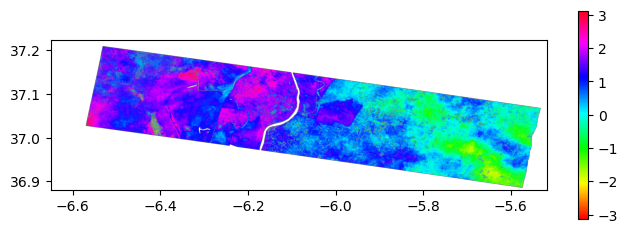

In [7]:
with rasterio.open('phase_coh_20180128T062713_20180203T062631.tif') as src:
    fig, ax = plt.subplots(figsize=(8, 6))
    im = show(src.read(1), transform=src.transform, cmap='hsv', ax=ax)
    cbar = fig.colorbar(im.get_images()[0], ax=ax, orientation="vertical", shrink=0.45)

Visualize the unwrapped interferogram

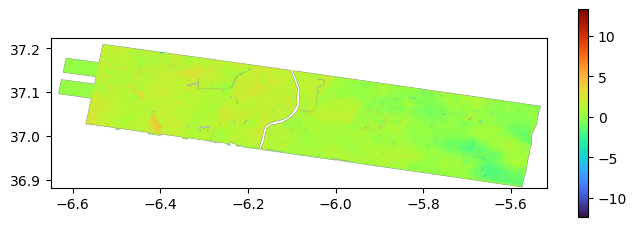

In [8]:
with rasterio.open('phase_coh_20180128T062713_20180203T062631.tif') as src:
    fig, ax = plt.subplots(figsize=(8, 6))
    im = show(src.read(2), transform=src.transform, cmap='turbo', ax=ax)
    cbar = fig.colorbar(im.get_images()[0], ax=ax, orientation="vertical", shrink=0.45)

Visualize the InSAR coherence

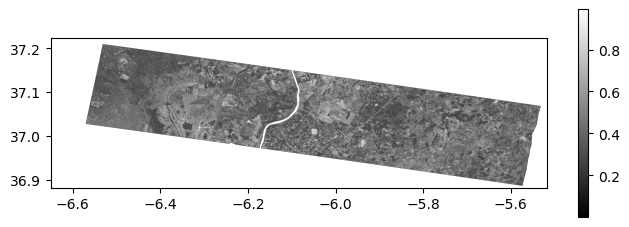

In [9]:
with rasterio.open('phase_coh_20180128T062713_20180203T062631.tif') as src:
    fig, ax = plt.subplots(figsize=(8, 6))
    im = show(src.read(3), transform=src.transform, cmap='gray', ax=ax)
    cbar = fig.colorbar(im.get_images()[0], ax=ax, orientation="vertical", shrink=0.45)